# Excel Data Cleaning & Formatting Project

## Project Objective
The objective of this project is to clean and organize a retail sales dataset by handling missing values, removing duplicates, correcting inconsistencies, and preparing the data for analysis.

## Importing Libraries and Loading Dataset

In [2]:
import pandas as pd
df = pd.read_csv("retail_store_sales.csv")

In [3]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


## Dataset Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [5]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [8]:
df.describe(include='all')

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
count,12575,12575,12575,11362,11966.000000,11971.000000,11971.000000,12575,12575,12575,8376
unique,12575,25,8,200,NaN,NaN,NaN,3,2,1114,2
top,TXN_6867343,CUST_05,Furniture,Item_2_BEV,NaN,NaN,NaN,Cash,Online,2022-05-30,True
freq,1,544,1591,126,NaN,NaN,NaN,4310,6354,26,4219
mean,NaN,NaN,NaN,NaN,23.365912,5.536380,129.652577,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,10.743519,2.857883,94.750697,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,5.000000,1.000000,5.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,14.000000,3.000000,51.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,23.000000,6.000000,108.500000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,33.500000,8.000000,192.000000,NaN,NaN,NaN,NaN


## Removing Duplicates and Handling Missing Values

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [14]:
numeric_cols = ['Price Per Unit', 'Quantity', 'Total Spent']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [15]:
df['Discount Applied'] = df['Discount Applied'].fillna(False)

In [16]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied       0
dtype: int64

In [17]:
df['Item'] = df['Item'].fillna(False)

## Basic Exploratory Analysis

In [18]:
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

In [19]:
df['Category'] = df['Category'].str.title()
df['Payment Method'] = df['Payment Method'].str.title()
df['Location'] = df['Location'].str.title()

In [20]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [21]:
df.describe()

,Price Per Unit,Quantity,Total Spent,Transaction Date
count,12575.000000,12575.000000,12575.000000,12575
mean,23.348191,5.558648,128.636581,2023-07-12 20:23:41.105368064
min,5.000000,1.000000,5.000000,2022-01-01 00:00:00
25%,14.000000,3.000000,55.000000,2022-09-30 00:00:00
50%,23.000000,6.000000,108.500000,2023-07-13 00:00:00
75%,32.000000,8.000000,184.000000,2024-04-24 00:00:00
max,41.000000,10.000000,410.000000,2025-01-18 00:00:00
std,10.480413,2.790160,92.557580,NaN


In [22]:
df[df['Price Per Unit'] < 0]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [23]:
df[df['Quantity'] < 0]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [24]:
df[df['Total Spent'] < 0]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [25]:
df['Calculated Total'] = df['Price Per Unit'] * df['Quantity']

In [26]:
inconsistent_totals = df[df['Calculated Total'] != df['Total Spent']]

inconsistent_totals.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Calculated Total
5,TXN_7482416,CUST_09,Patisserie,False,23.0,10.0,200.0,Credit Card,Online,2023-11-30,False,230.0
7,TXN_1372952,CUST_21,Furniture,False,33.5,6.0,108.5,Digital Wallet,In-Store,2024-04-02,True,201.0
11,TXN_5422631,CUST_09,Milk Products,False,23.0,8.0,52.0,Digital Wallet,In-Store,2025-01-12,True,184.0
15,TXN_1809665,CUST_14,Beverages,False,24.5,6.0,108.5,Credit Card,In-Store,2022-05-11,False,147.0
17,TXN_9634894,CUST_15,Milk Products,False,23.0,10.0,275.0,Digital Wallet,Online,2022-04-17,False,230.0


In [27]:
df['Total Spent'] = df['Calculated Total']

In [28]:
df.drop(columns=['Calculated Total'], inplace=True)

In [29]:
df['Category'].value_counts()

Category
Furniture                             1591
Electric Household Essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers And Electric Accessories    1558
Patisserie                            1528
Name: count, dtype: int64

In [30]:
df['Total Spent'].mean()

np.float64(130.11495029821074)

In [31]:
df['Payment Method'].value_counts()

Payment Method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64

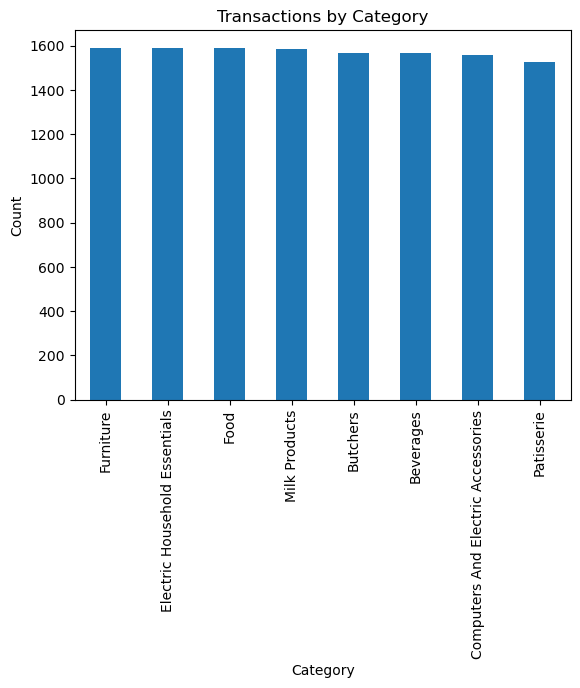

In [32]:
import matplotlib.pyplot as plt

df['Category'].value_counts().plot(kind='bar')

plt.title('Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Count')

plt.show()

In [33]:
df.to_csv("cleaned_retail_store_sales_final.csv", index=False)

## Final Result

The dataset was successfully cleaned and prepared for future analysis and reporting.